# Clusterização de Iris

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import optuna

from sklearn.mixture import GaussianMixture
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

## Ler dataset

In [57]:
df_iris = load_iris(as_frame=True).frame
df_iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [58]:
df_iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## Pré-processo dos Dados

In [59]:
X = df_iris.drop(columns=['target']).copy()

numeric_features = X.columns.tolist()
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(transformers=[
  ('num', numeric_transformer, numeric_features)
])

X_transformed = preprocessor.fit_transform(X)
X_transformed.shape

(150, 4)

## Criação da Função de Tuning

In [60]:
def iris_objective(trial: optuna.Trial):
    covariance_type = trial.suggest_categorical('covariance_type', ['full', 'tied', 'diag', 'spherical'])

    model_opt = GaussianMixture(
      covariance_type=covariance_type, # type: ignore
      random_state=51,
      n_components=3
    )

    model_opt.fit(X_transformed)

    return model_opt.bic(X_transformed)

## Tuning de Hiperparâmetros

In [ ]:
search_space = {
  'covariance_type': ['full', 'tied', 'diag', 'spherical'],
}
sampler = optuna.samplers.GridSampler(
  search_space=search_space,
)
gmm_study = optuna.create_study(
  sampler=sampler,
  direction='minimize',
  study_name='GMM Study',
)
gmm_study.optimize(
  func=iris_objective, # type: ignore
  n_trials=len(search_space['covariance_type']),
  n_jobs=-1
)

[I 2026-07-31 03:16:34,721] A new study created in memory with name: GMM Study
[I 2026-07-31 03:16:34,779] Trial 1 finished with value: 1227.1546992005408 and parameters: {'covariance_type': 'spherical'}. Best is trial 1 with value: 1227.1546992005408.
[I 2026-07-31 03:16:34,804] Trial 0 finished with value: 965.8167981514779 and parameters: {'covariance_type': 'diag'}. Best is trial 0 with value: 965.8167981514779.
[I 2026-07-31 03:16:34,904] Trial 2 finished with value: 854.53265197039 and parameters: {'covariance_type': 'tied'}. Best is trial 2 with value: 854.53265197039.
[I 2026-07-31 03:16:34,948] Trial 3 finished with value: 801.5535017494136 and parameters: {'covariance_type': 'full'}. Best is trial 3 with value: 801.5535017494136.


## Selecionar melhor modelo

In [63]:
best_params = gmm_study.best_params
best_params

{'covariance_type': 'full'}

In [64]:
gmm_model = GaussianMixture(
  n_components=3,
  covariance_type=best_params['covariance_type'],
  random_state=51,
)

clusters = gmm_model.fit_predict(X_transformed)


df_iris['cluster'] = clusters

df_iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   cluster            150 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 7.2 KB


## Realizar crosstab

In [ ]:
crosstab = pd.crosstab(df_iris['target'], df_iris['cluster'])

cluster,0,1,2
target,,,
0,0,50,0
1,45,0,5
2,0,0,50


### Visualizar crosstab

Text(0.5, 1.0, 'Target x Cluster')

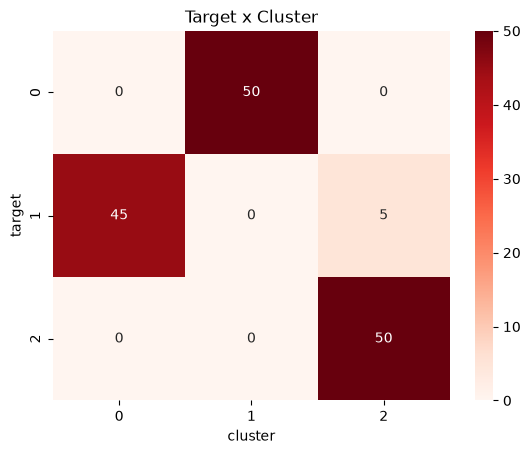

In [ ]:
sns.heatmap(
  crosstab,
  annot=True,
  cmap='Reds',
  fmt="d",
  vmin=0,
  vmax=50,
)
plt.title("Target x Cluster")